# 02 · Preprocessing and feature selection

Every step here is **fitted on the training split only** and then applied unchanged to the test split and the VUS, so nothing leaks from test into training.

| Step | Method | Figure |
|---|---|---|
| Missing values | missingness audit, MCAR check, imputer comparison, median imputation | 11, 12 |
| Outliers | Tukey IQR fences (1.5 × IQR), winsorisation (cap, not drop) | 13 |
| Normalisation | log10 for skewed features, then z-score (mean 0, SD 1) | 14 |
| Correlation | Spearman correlation, redundancy filter at abs(rho) > 0.85 | 15 |
| Feature selection | FDR q < 0.05 **and** mutual information ≥ 0.005 **and** non-redundant | 16 |

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/vus-reclassification


In [2]:
# Make sure the processed splits exist (runs the data stage if needed).
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()

from src.data.make_dataset import load_split, get_xy
from src.features import build_features as bf

train, test = load_split("train"), load_split("test")
print("train", train.shape, "| test", test.shape)
train[cfg.TARGET_COL].value_counts()

train (2455, 30) | test (614, 30)


Classification
Benign        1909
Pathogenic     546
Name: count, dtype: int64

## 1. Missing values
About 13% of cells are missing. First we look at the pattern, then test whether missingness depends on the class (it should not if the data are Missing Completely At Random).

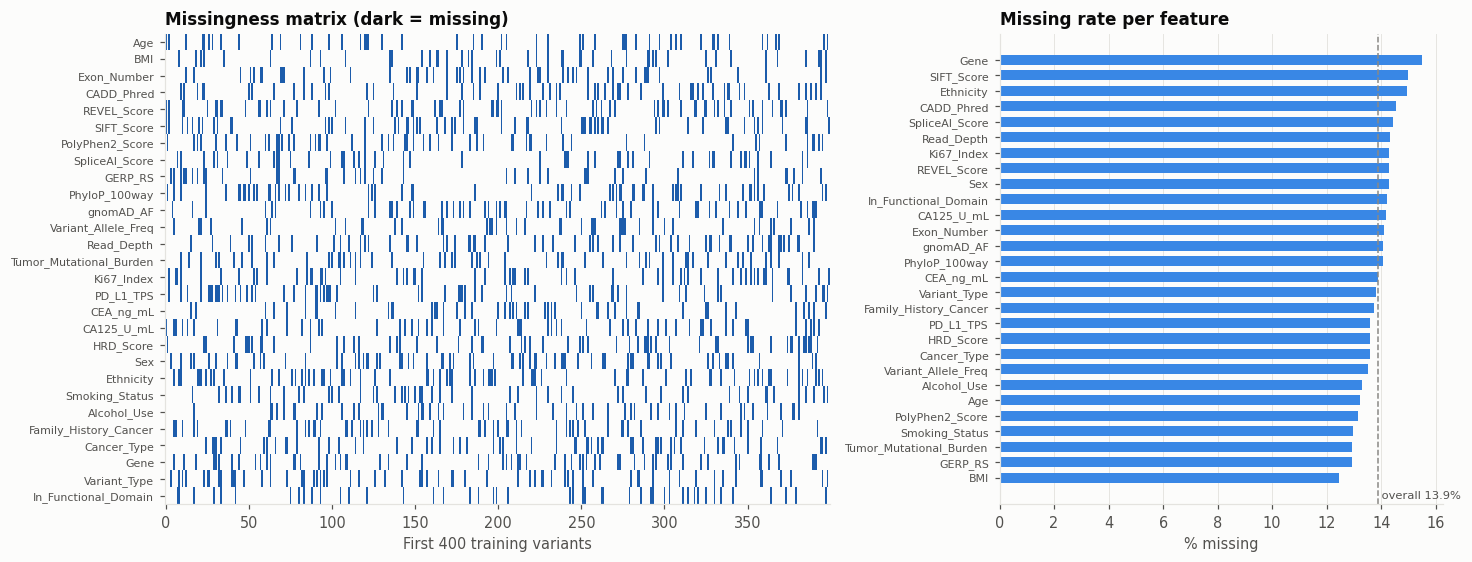

In [3]:
bf.plot_missingness(train);

In [4]:
mbc = bf.missing_by_class(train)
print(f"Features where missingness differs by class (p < 0.05): {(mbc.chi2_p < 0.05).sum()} of {len(mbc)}")
mbc.sort_values("chi2_p").head(8).round(4)

Features where missingness differs by class (p < 0.05): 3 of 28


,feature,missing_benign,missing_pathogenic,chi2_p
23,Family_History_Cancer,0.1268,0.1740,0.0058
25,Gene,0.1655,0.1172,0.0072
3,CADD_Phred,0.1362,0.1777,0.0186
14,Ki67_Index,0.1503,0.1172,0.0600
15,PD_L1_TPS,0.1425,0.1136,0.0953
17,CA125_U_mL,0.1357,0.1630,0.1224
6,PolyPhen2_Score,0.1372,0.1117,0.1378
11,Variant_Allele_Freq,0.1299,0.1538,0.1703


Next, feature selection runs first (on simply imputed data) so the imputer comparison uses the final feature set.

In [5]:
sel = bf.select_features(train)
selected = sel["selected"]
print(len(selected), "selected features:", selected)

16 selected features: ['REVEL_Score', 'PolyPhen2_Score', 'gnomAD_AF', 'CADD_Phred', 'GERP_RS', 'HRD_Score', 'SIFT_Score', 'PhyloP_100way', 'SpliceAI_Score', 'Tumor_Mutational_Burden', 'Variant_Allele_Freq', 'Age', 'Ki67_Index', 'Variant_Type', 'In_Functional_Domain', 'Family_History_Cancer']


In [6]:
imp = bf.compare_imputers(train, selected)   # 5-fold CV AUC with a logistic-regression probe
imp.round(4)

,imputer,cv_auc_mean,cv_auc_sd
0,mean,0.9325,0.0047
1,median,0.9322,0.0044
2,knn,0.9300,0.0041
3,iterative,0.9324,0.0049


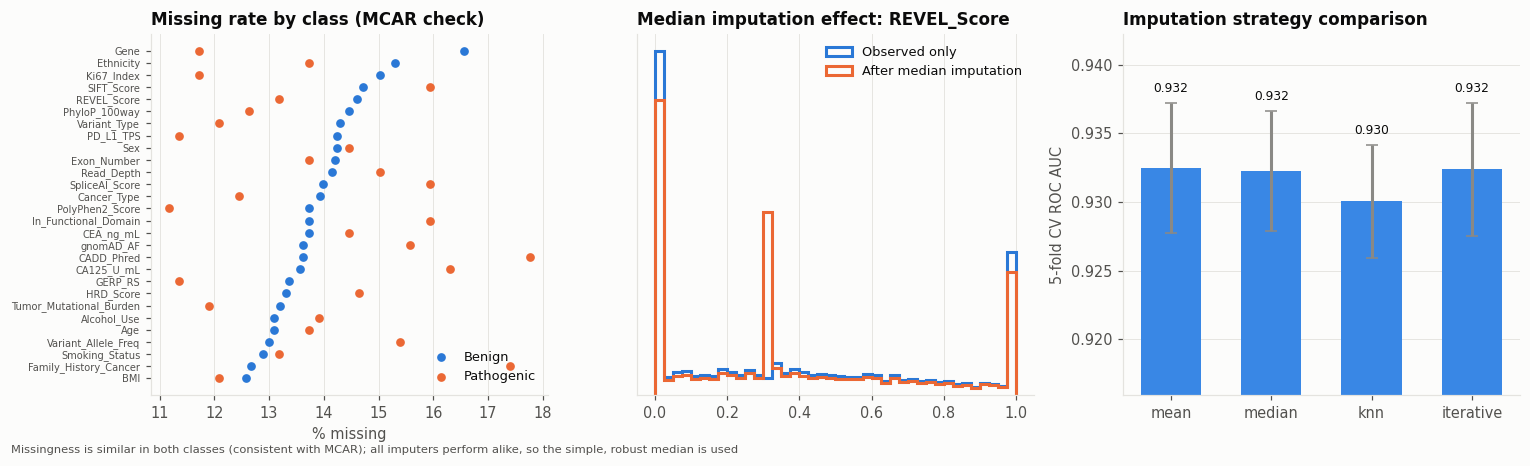

In [7]:
bf.plot_missing_handling(train, mbc, imp, selected);

Missingness looks random with respect to class, and the four imputers perform within about 0.002 AUC of each other. **Median imputation** is used: it is simple, robust to outliers and easy to reproduce in production. Categorical features use the most frequent level.

## 2. Outlier analysis
Tukey fences are learned on the training data. Values beyond them are **capped**, so no variant is thrown away and extreme values cannot dominate the SVM or the Transformer.

In [8]:
otab = bf.outlier_table(train)
otab.round(3)

,feature,lower_fence,upper_fence,n_low,n_high,pct_outliers,n_abs_z_gt_3
13,Tumor_Mutational_Burden,-26.606,44.344,0,18,0.842,19
15,PD_L1_TPS,-25.700,70.300,0,8,0.377,5
8,GERP_RS,-11.690,14.790,8,0,0.374,8
12,Read_Depth,22.500,618.500,4,3,0.333,2
0,Age,19.000,91.000,7,0,0.329,0
9,PhyloP_100way,-16.280,21.000,4,0,0.190,4
1,BMI,14.250,41.050,0,4,0.186,1
2,Exon_Number,-14.000,42.000,0,0,0.000,0
6,PolyPhen2_Score,-1.227,2.045,0,0,0.000,0
3,CADD_Phred,-35.732,60.108,0,0,0.000,0


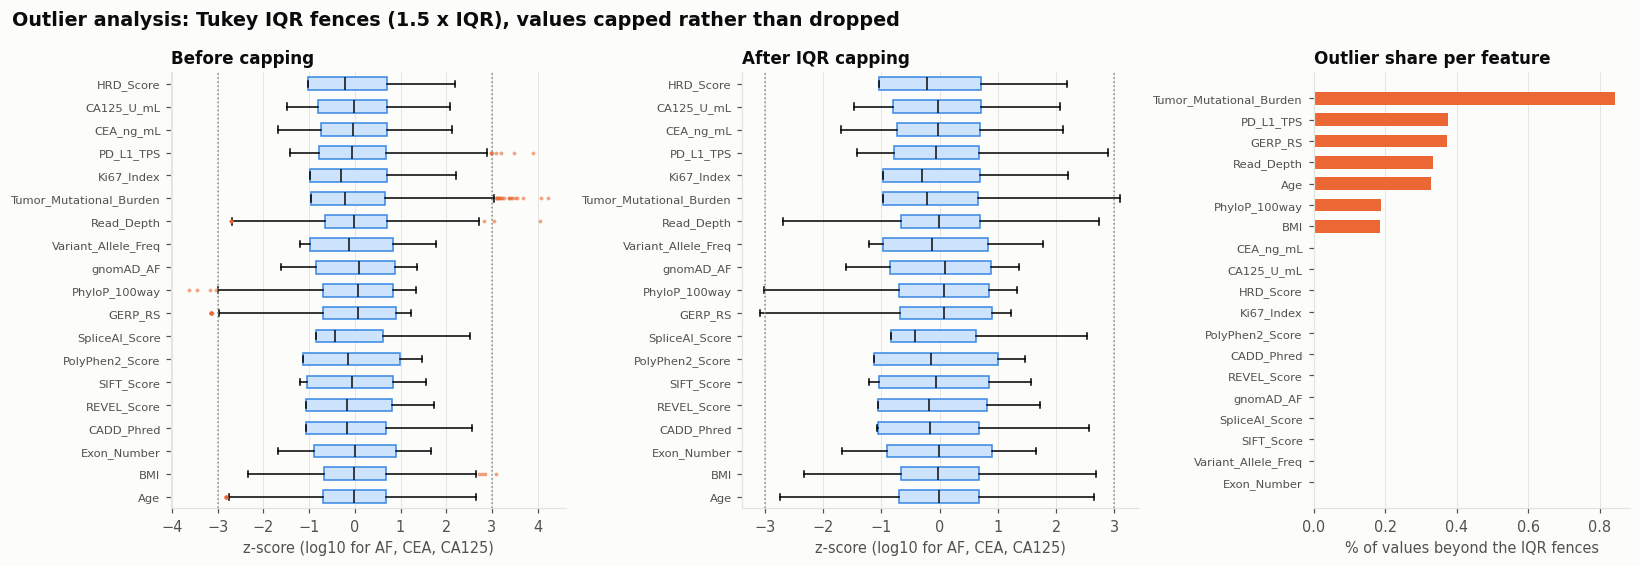

In [9]:
bf.plot_outliers(train, otab);

## 3. z-score normalisation
The right-skewed features (gnomAD AF, CEA, CA125) are log10-transformed first. After capping and imputation every numeric feature is standardised to mean 0 and SD 1. This matters for the RBF-SVM (distance based) and the Transformer (gradient based); XGBoost is scale-invariant but uses the same pipeline for consistency.

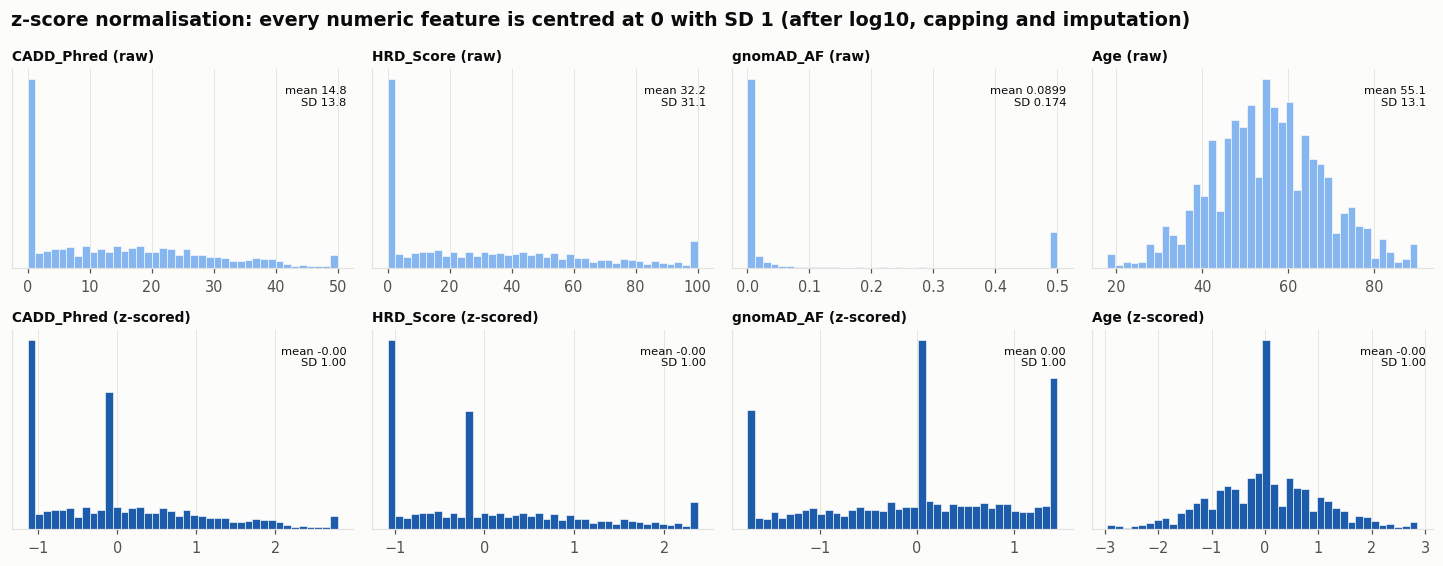

In [10]:
bf.plot_zscore(train, selected);

## 4. Correlation analysis
Spearman correlation (robust to outliers and monotone non-linearity), ordered by hierarchical clustering. Grey labels are features removed by selection.

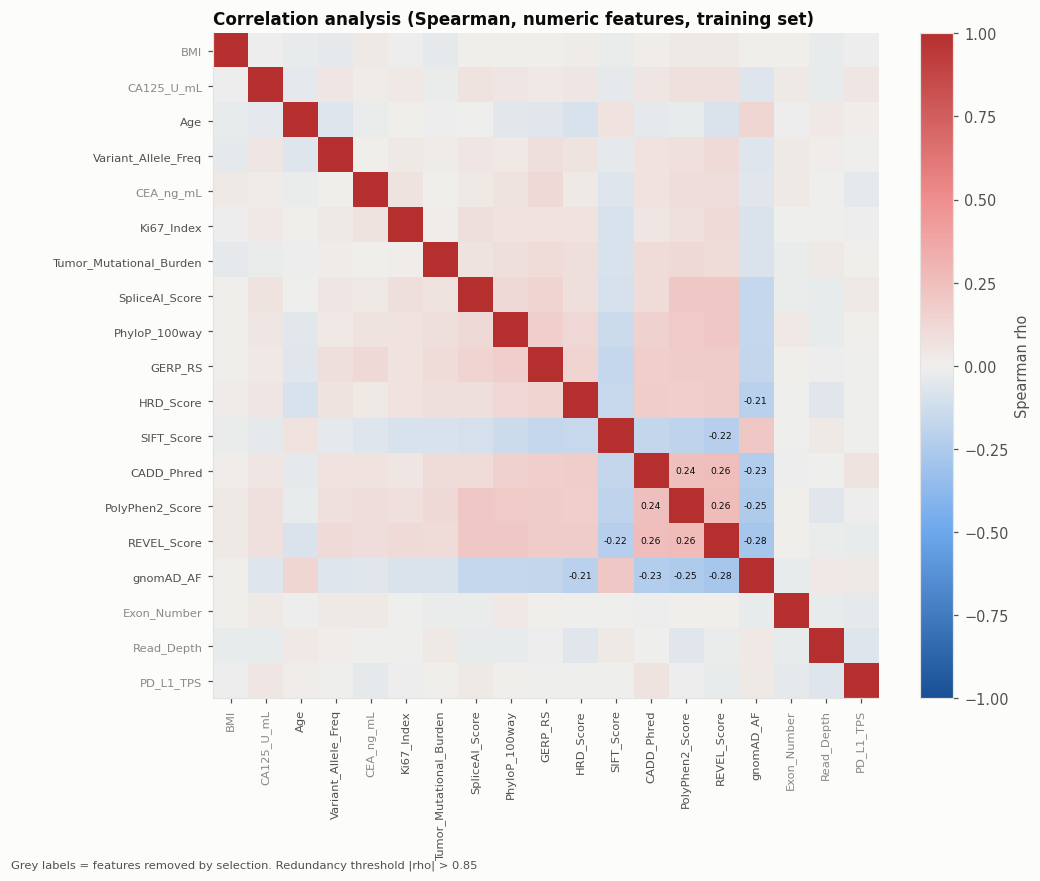

In [11]:
bf.plot_correlation(train, selected);

## 5. Feature selection
Three rules applied to the training data:
1. significant association with the label after FDR correction (q < 0.05)
2. mutual information ≥ 0.005 nats
3. no redundancy: among pairs with abs(rho) > 0.85, the feature with lower MI is dropped

In [12]:
sel["table"][["feature", "group", "type", "q_value", "mutual_info", "reason"]].round(5)

,feature,group,type,q_value,mutual_info,reason
0,Variant_Type,Genomic,categorical,0.00000,0.10310,kept
1,REVEL_Score,Genomic,numeric,0.00000,0.09574,kept
2,PolyPhen2_Score,Genomic,numeric,0.00000,0.08200,kept
3,gnomAD_AF,Genomic,numeric,0.00000,0.07402,kept
4,In_Functional_Domain,Genomic,categorical,0.00000,0.07095,kept
5,Family_History_Cancer,Demography,categorical,0.00000,0.05570,kept
6,GERP_RS,Genomic,numeric,0.00000,0.04989,kept
7,CADD_Phred,Genomic,numeric,0.00000,0.04729,kept
8,SIFT_Score,Genomic,numeric,0.00000,0.04523,kept
9,SpliceAI_Score,Genomic,numeric,0.00000,0.04402,kept


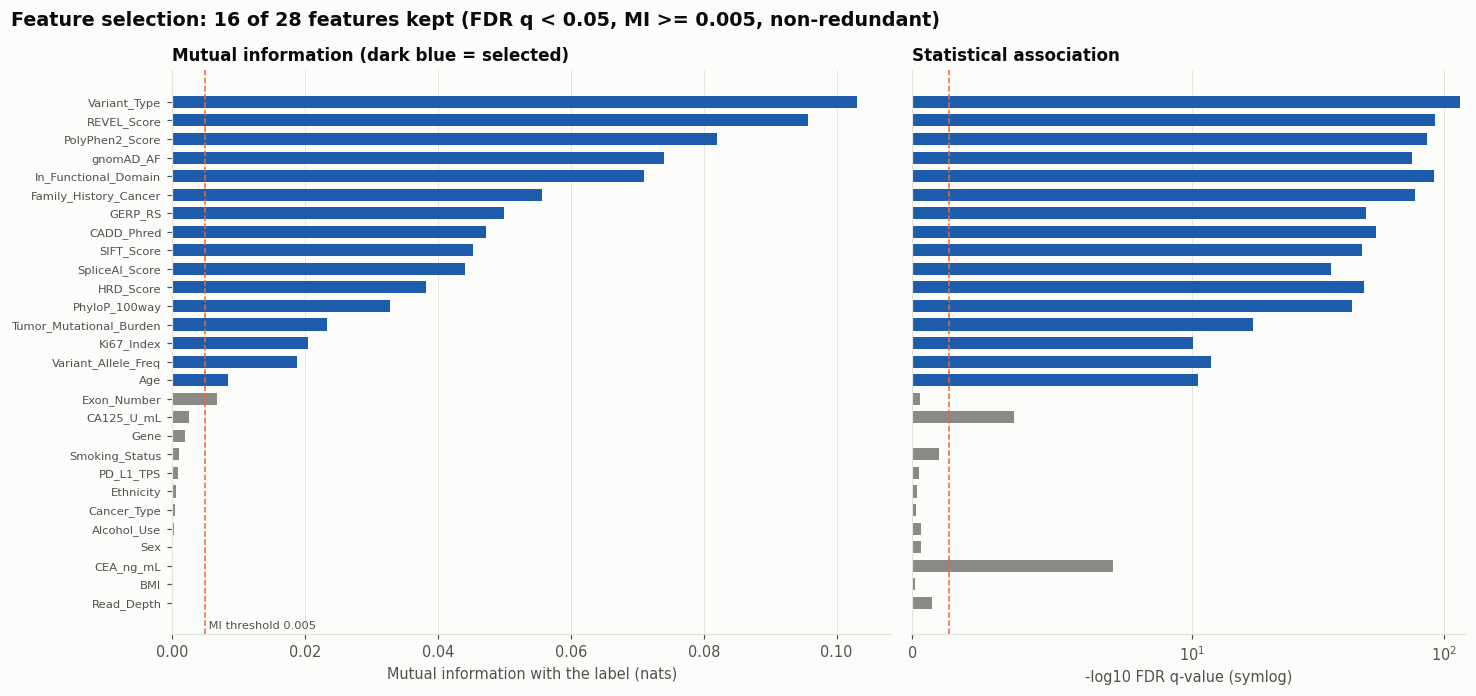

In [13]:
bf.plot_feature_selection(sel["table"]);

All the pure-noise columns (BMI, sex, ethnicity, smoking, alcohol, cancer type, gene, exon, read depth, PD-L1) are removed, along with CEA and CA125, which are statistically significant but carry almost no information. No numeric pair exceeded the redundancy threshold.

## 6. Build and inspect the final preprocessing pipeline

In [14]:
num, cat = bf.split_types(selected)
prep = bf.build_preprocessor(num, cat)
prep

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('log10', ...), ('columns', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,['gnomAD_AF']
,floor,1e-08
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output o

In [15]:
Xtr, ytr = get_xy(train, selected)
Xt = pd.DataFrame(prep.fit_transform(Xtr), columns=prep.get_feature_names_out())
print("Transformed training matrix:", Xt.shape, "| any NaN left:", bool(Xt.isna().any().any()))
Xt.describe().T[["mean", "std", "min", "max"]].round(3).head(15)

Transformed training matrix: (2455, 20) | any NaN left: False


,mean,std,min,max
REVEL_Score,-0.000,1.000,-1.120,1.884
PolyPhen2_Score,0.000,1.000,-1.188,1.592
gnomAD_AF,0.000,1.000,-1.745,1.448
CADD_Phred,-0.000,1.000,-1.135,2.790
GERP_RS,0.000,1.000,-3.312,1.307
HRD_Score,-0.000,1.000,-1.079,2.372
SIFT_Score,-0.000,1.000,-1.301,1.713
PhyloP_100way,0.000,1.000,-3.263,1.429
SpliceAI_Score,0.000,1.000,-0.834,2.762
Tumor_Mutational_Burden,0.000,1.000,-1.009,3.364


In [16]:
# Run the whole stage as the Makefile does (writes selected_features.json, tables, figures)
_ = bf.run(); plt.close("all")
print(open(cfg.SELECTED_FEATURES_FILE).read()[:600])

16:33:40 | INFO    | src.features.build_features | Selected 16 features: ['REVEL_Score', 'PolyPhen2_Score', 'gnomAD_AF', 'CADD_Phred', 'GERP_RS', 'HRD_Score', 'SIFT_Score', 'PhyloP_100way', 'SpliceAI_Score', 'Tumor_Mutational_Burden', 'Variant_Allele_Freq', 'Age', 'Ki67_Index', 'Variant_Type', 'In_Functional_Domain', 'Family_History_Cancer']


16:33:45 | INFO    | src.features.build_features | Imputer comparison:
  imputer  cv_auc_mean  cv_auc_sd
     mean       0.9325     0.0047
   median       0.9322     0.0044
      knn       0.9300     0.0041
iterative       0.9324     0.0049


{
  "selected_features": [
    "REVEL_Score",
    "PolyPhen2_Score",
    "gnomAD_AF",
    "CADD_Phred",
    "GERP_RS",
    "HRD_Score",
    "SIFT_Score",
    "PhyloP_100way",
    "SpliceAI_Score",
    "Tumor_Mutational_Burden",
    "Variant_Allele_Freq",
    "Age",
    "Ki67_Index",
    "Variant_Type",
    "In_Functional_Domain",
    "Family_History_Cancer"
  ],
  "numeric": [
    "REVEL_Score",
    "PolyPhen2_Score",
    "gnomAD_AF",
    "CADD_Phred",
    "GERP_RS",
    "HRD_Score",
    "SIFT_Score",
    "PhyloP_100way",
    "SpliceAI_Score",
    "Tumor_Mutational_Burden",
    "Variant_Allele
